In [1]:
import pandas as pd
df = pd.read_csv("/StockPriceDataset.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2014-01-02,19.845715,19.893929,19.715000,19.754642,17.273226,234684800,AAPL
1,2014-01-03,19.745001,19.775000,19.301071,19.320715,16.893808,392467600,AAPL
2,2014-01-06,19.194643,19.528570,19.057142,19.426071,16.985926,412610800,AAPL
3,2014-01-07,19.440001,19.498571,19.211430,19.287144,16.864458,317209200,AAPL
4,2014-01-08,19.243214,19.484285,19.238930,19.409286,16.971254,258529600,AAPL


In [19]:
#Task 2

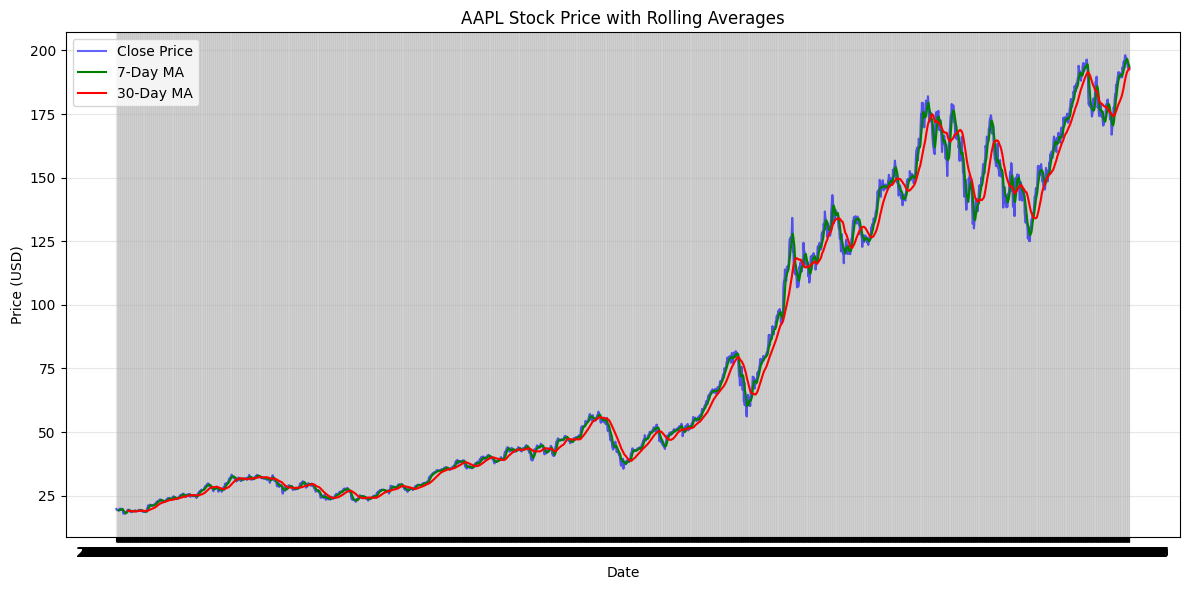

In [4]:
#Line Plot with Rolling Averages / Trend Overlays
stock_df = df[df['Ticker'] == 'AAPL'].sort_values('Date')
stock_df['MA_7'] = stock_df['Close'].rolling(7).mean()
stock_df['MA_30'] = stock_df['Close'].rolling(30).mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(stock_df['Date'], stock_df['Close'], label='Close Price', color='blue', alpha=0.6)
plt.plot(stock_df['Date'], stock_df['MA_7'], label='7-Day MA', color='green')
plt.plot(stock_df['Date'], stock_df['MA_30'], label='30-Day MA', color='red')

plt.title("AAPL Stock Price with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


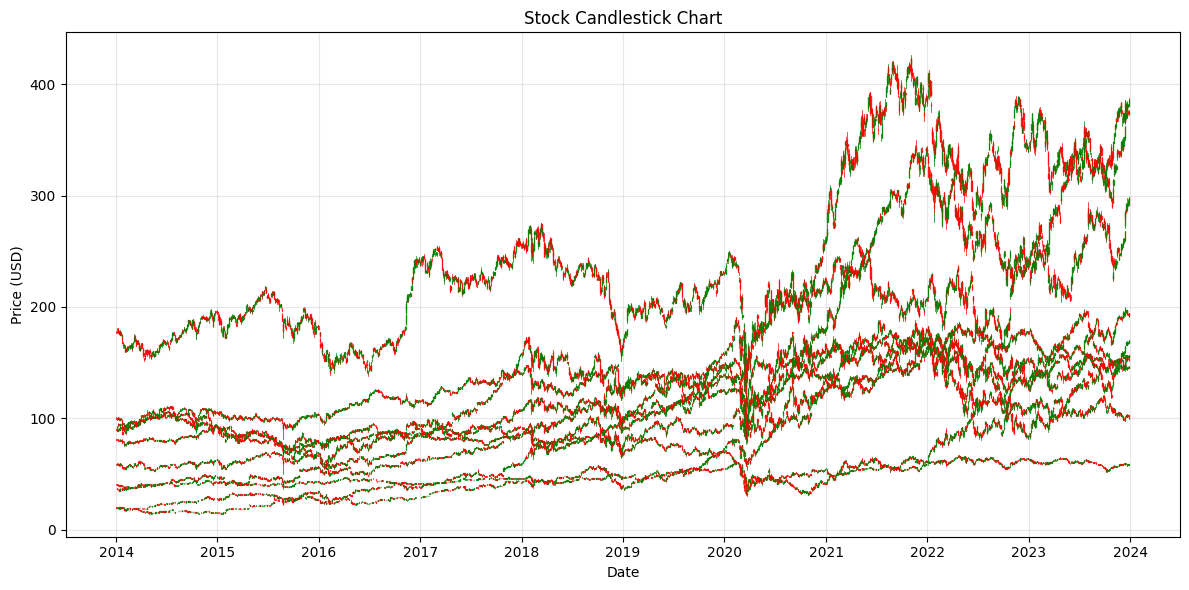

In [17]:
#Candlestick Chart for Financial Data
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc
import pandas as pd

# Load your dataset
df = pd.read_csv("/StockPriceDataset.csv")

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Prepare OHLC data for candlestick
ohlc = df[['Date', 'Open', 'High', 'Low', 'Close']].copy()
ohlc['Date'] = mdates.date2num(ohlc['Date'])

# Plot candlestick chart
fig, ax = plt.subplots(figsize=(12,6))
candlestick_ohlc(
    ax,
    ohlc.values,
    width=0.6,
    colorup='green',
    colordown='red',
    alpha=0.8
)

# Formatting
ax.xaxis_date()
ax.set_title("Stock Candlestick Chart")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


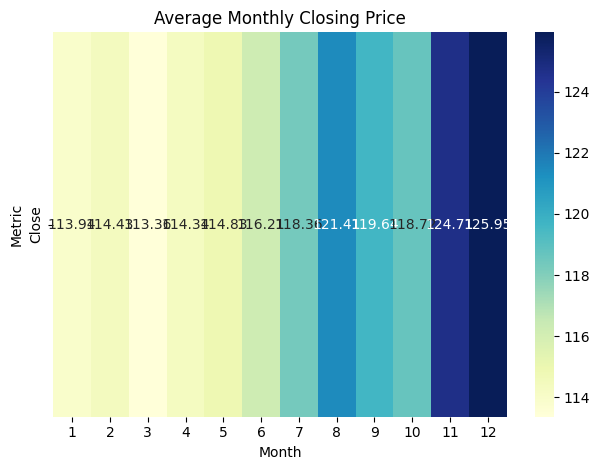

In [12]:
#Heatmap for Intensity-Based Patterns
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure Date column is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create Month column
df['Month'] = df['Date'].dt.month

# Group by Month and calculate average Close price
pivot_df = df.groupby('Month')['Close'].mean().to_frame()

# Transpose for seaborn heatmap
sns.heatmap(pivot_df.T, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title("Average Monthly Closing Price")
plt.xlabel("Month")
plt.ylabel("Metric")
plt.tight_layout()
plt.show()


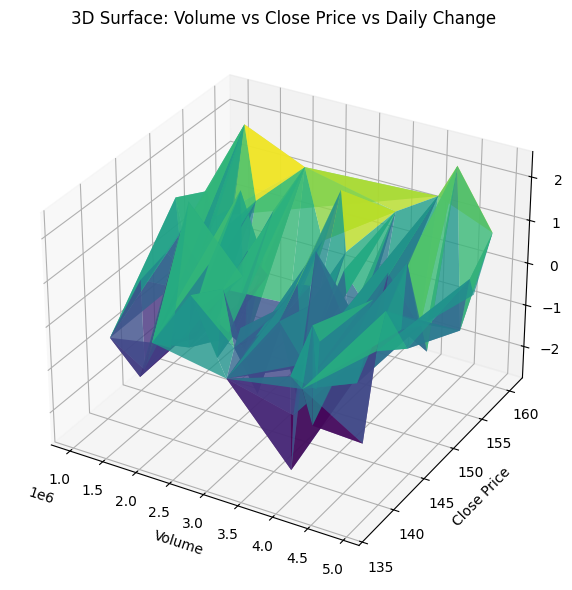

In [16]:
#3D Surface Plot for Multi-Variable Relationships
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Create a synthetic stock dataset
np.random.seed(42)
dates = pd.date_range(start="2023-01-01", periods=180, freq='D')
price = 150
data = []

for d in dates:
    open_p = price + np.random.uniform(-2, 2)
    high_p = open_p + np.random.uniform(0, 3)
    low_p = open_p - np.random.uniform(0, 3)
    close_p = np.random.uniform(low_p, high_p)
    volume = np.random.randint(1_000_000, 5_000_000)
    price = close_p
    data.append([d, open_p, high_p, low_p, close_p, volume])

df = pd.DataFrame(data, columns=["Date","Open","High","Low","Close","Volume"])

# 2. Create necessary derived columns
df['Daily Change'] = df['Close'] - df['Open']   # required for 3D surface
df['Return %'] = (df['Close'] - df['Open']) / df['Open'] * 100
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()

# 3. Sample 100 points for 3D clarity
sample_df = df.sample(100, random_state=42)

# 4. Plot 3D surface
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_trisurf(
    sample_df['Volume'],
    sample_df['Close'],
    sample_df['Daily Change'],
    cmap='viridis',
    edgecolor='none',
    alpha=0.8
)

ax.set_xlabel("Volume")
ax.set_ylabel("Close Price")
ax.set_zlabel("Daily Change")
ax.set_title("3D Surface: Volume vs Close Price vs Daily Change")
plt.tight_layout()
plt.show()


In [18]:
#Task 3

In [20]:
import pandas as pd
import numpy as np

# Synthetic stock data
np.random.seed(42)
dates = pd.date_range(start="2023-01-01", periods=180, freq='D')
price = 150
data = []

for d in dates:
    open_p = price + np.random.uniform(-2, 2)
    high_p = open_p + np.random.uniform(0, 3)
    low_p = open_p - np.random.uniform(0, 3)
    close_p = np.random.uniform(low_p, high_p)
    volume = np.random.randint(1_000_000, 5_000_000)
    price = close_p
    data.append([d, open_p, high_p, low_p, close_p, volume])

df = pd.DataFrame(data, columns=["Date","Open","High","Low","Close","Volume"])

# Derived columns
df['Daily Change'] = df['Close'] - df['Open']
df['Return %'] = (df['Close'] - df['Open']) / df['Open'] * 100
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()
df['MA_7'] = df['Close'].rolling(7).mean()
df['MA_30'] = df['Close'].rolling(30).mean()


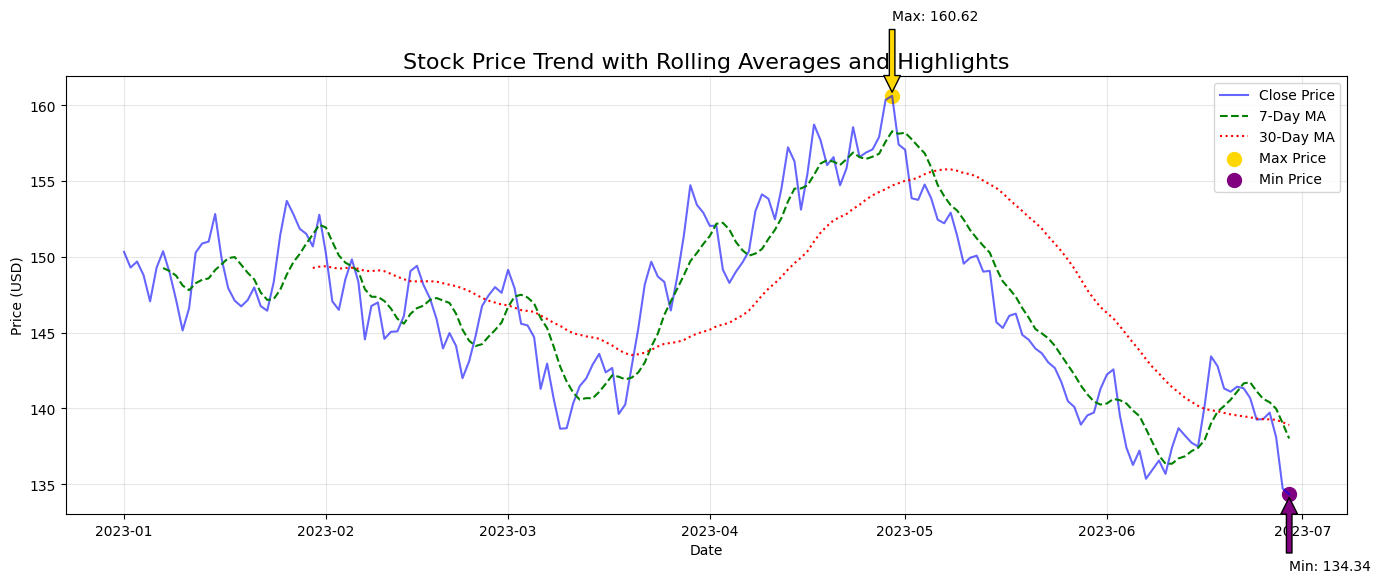

In [30]:
#Line Plot with Highlights and Annotations
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Plot closing price
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue', alpha=0.6)

# Plot rolling averages
plt.plot(df['Date'], df['MA_7'], label='7-Day MA', color='green', linestyle='--')
plt.plot(df['Date'], df['MA_30'], label='30-Day MA', color='red', linestyle=':')

# Highlight max and min
max_price = df['Close'].max()
min_price = df['Close'].min()
max_date = df['Date'][df['Close'].idxmax()]
min_date = df['Date'][df['Close'].idxmin()]

plt.scatter(max_date, max_price, color='gold', s=100, label='Max Price')
plt.scatter(min_date, min_price, color='purple', s=100, label='Min Price')
plt.annotate(f'Max: {max_price:.2f}', xy=(max_date, max_price), xytext=(max_date, max_price+5),
             arrowprops=dict(facecolor='gold', shrink=0.05))
plt.annotate(f'Min: {min_price:.2f}', xy=(min_date, min_price), xytext=(min_date, min_price-5),
             arrowprops=dict(facecolor='purple', shrink=0.05))

# Customization
plt.title("Stock Price Trend with Rolling Averages and Highlights", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


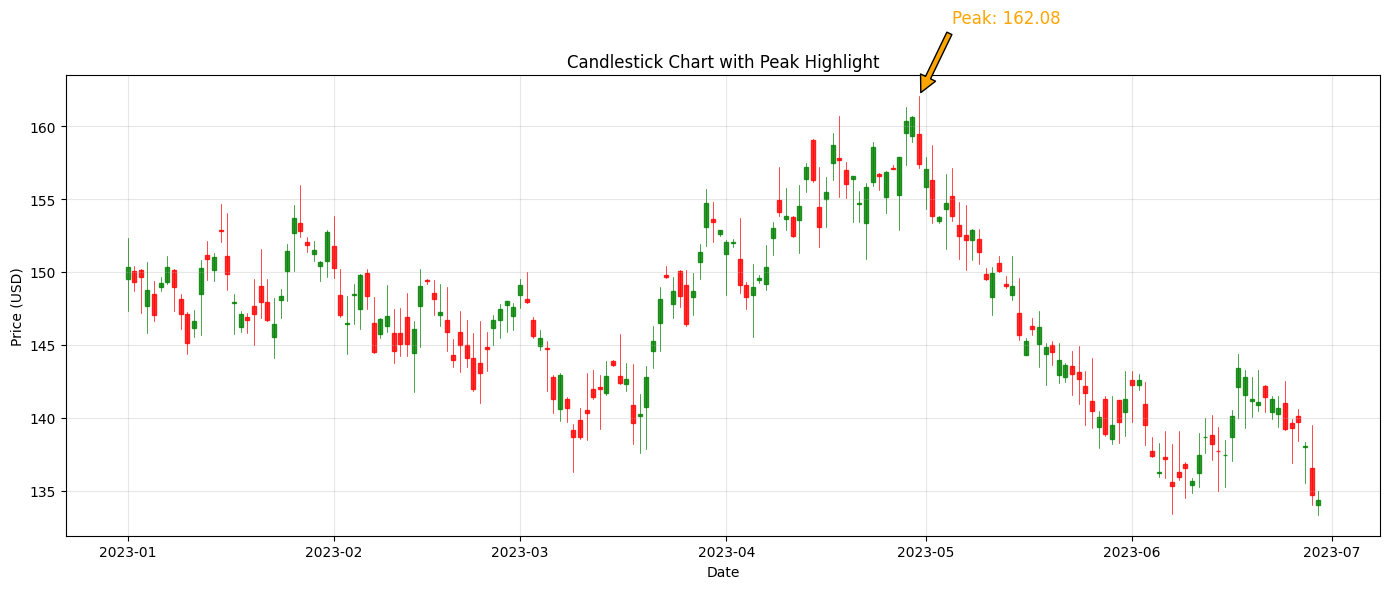

In [28]:
#Candlestick Chart with Highlighted Peaks/Drops
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc

ohlc = df[['Date','Open','High','Low','Close']].copy()
ohlc['Date'] = mdates.date2num(ohlc['Date'])

fig, ax = plt.subplots(figsize=(14,6))
candlestick_ohlc(ax, ohlc.values, width=0.6, colorup='green', colordown='red', alpha=0.8)

# Highlight the highest high
max_high = df['High'].max()
max_high_date = df['Date'][df['High'].idxmax()]
ax.annotate(f'Peak: {max_high:.2f}', xy=(mdates.date2num(max_high_date), max_high),
            xytext=(mdates.date2num(max_high_date)+5, max_high+5),
            arrowprops=dict(facecolor='orange', shrink=0.05), fontsize=12, color='orange')

# Formatting
ax.xaxis_date()
ax.set_title("Candlestick Chart with Peak Highlight")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


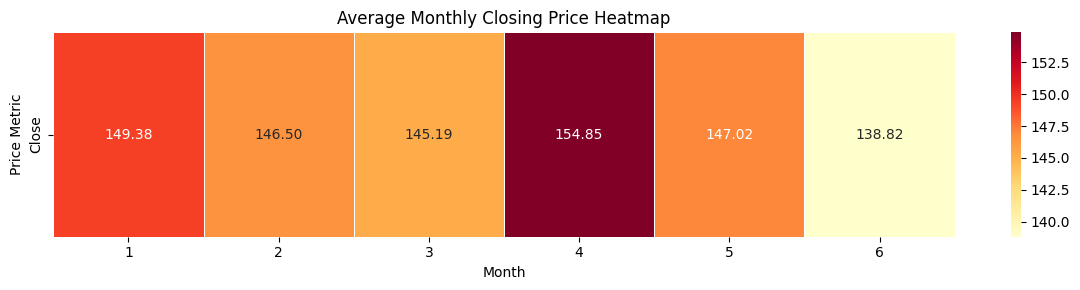

In [27]:
#Heatmap of Average Monthly Close Prices
import seaborn as sns

# Pivot: Average Close per Month
pivot_df = df.groupby('Month')['Close'].mean().to_frame()

plt.figure(figsize=(12,3))
sns.heatmap(pivot_df.T, cmap='YlOrRd', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Average Monthly Closing Price Heatmap")
plt.xlabel("Month")
plt.ylabel("Price Metric")
plt.tight_layout()
plt.show()


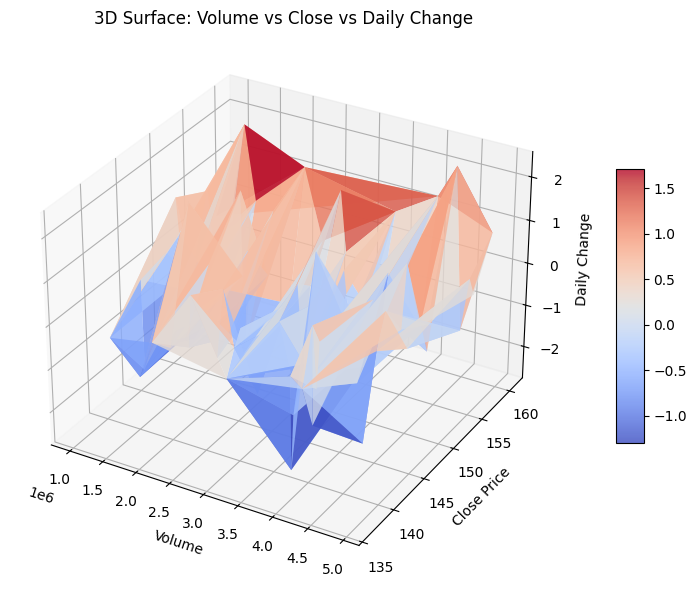

In [26]:
#3D Surface Plot for Volume vs Price vs Daily Change
from mpl_toolkits.mplot3d import Axes3D

sample_df = df.sample(100, random_state=42)

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_trisurf(sample_df['Volume'], sample_df['Close'], sample_df['Daily Change'],
                       cmap='coolwarm', edgecolor='none', alpha=0.8)

ax.set_xlabel("Volume")
ax.set_ylabel("Close Price")
ax.set_zlabel("Daily Change")
ax.set_title("3D Surface: Volume vs Close vs Daily Change")
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.tight_layout()
plt.show()
